# Simon's Algorithm

Problem: $f:\{0,1\}^n \to \{0,1\}^m$ with $m \ge n$ is a $1:1$ or $2:1$ function mapping an $n$-bit string to an $m$-bit string with a period $s \in \{0,1\}^n$ such that for all $x, y$, $f(x) = f(y)$ if and only if $y = x \oplus s$. If $f$ is 1:1, the period $s$ is 0, while if it is $2:1$, $s$ is nonzero. Find the period $s$, and thus from there also determine what type of function $f$ is. 

Classical solution takes at least $2^{n/2}$ queries to $f$ even randomized, while the quantum algorithm achieves it in $O(n)$, thus achieving a true exponential separation.

For simplicity in this notebook I chose to only take the algorithm up through the quantum step, building the oracle and determining $n$-bit strings $y$ for which $y \cdot s \bmod 2 = 0$. Taking $n-1$ such bitstrings provides a system of linear equations from which determining $s$ becomes classically easy, but requires Gaussian elimination, which is standard linear algebra diverging from the quantum focus of this exploration.


In [61]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from IPython.display import display

In [62]:
def make_oracle(s):
    def oracle(qc):
        n = len(s)
        for i in range(n):
            qc.cx(i, n + i) #copying input register into output
        if '1' in s: #XORs controlled on first 1 in s
            k = s.index('1')
            for j in range(n):
                if s[j] == '1':
                    qc.cx(k,n+j)
        #skips if s = 0^n - f unchanged, 1:1
        return qc
    return oracle

In [63]:
def make_simon_circuit(n, oracle):
    qc = QuantumCircuit(2*n,n)
    for i in range(n):
        qc.h(i)
    oracle(qc)
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.measure(i,i)
    return qc

In [64]:
def dot_product_mod2(y, s):
    return sum(int(yi) * int(si) for yi, si in zip(y, s)) % 2

In [65]:
def run_simon(n,s):
    oracle = make_oracle(s)
    circuit = make_simon_circuit(n, oracle)
    print(f'Simon Circuit for {s}:')
    display(circuit.draw('mpl'))
    sampler = StatevectorSampler(default_shots=1000)
    result = sampler.run([circuit]).result()
    counts = result[0].data.c.get_counts()
    for outcome, count in counts.items():
        print(f'y: {outcome[::-1]} - Count: {count}')
        print(f'Dot Product of y and s mod 2: {dot_product_mod2(outcome[::-1], s)}') 
        
    print(f'{n}-bit strings y for which mod 2 dot product with unknown bitstring s yields 0. Using this information, we would setup a system of equations to thus retrieve s')

Simon Circuit for 101:


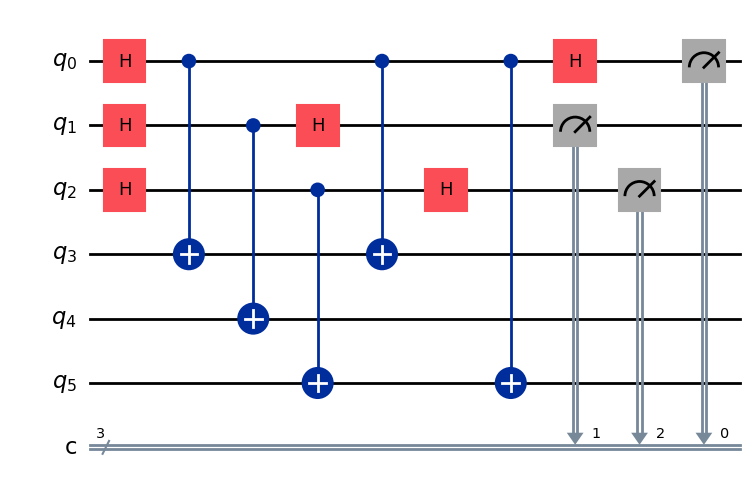

y: 111 - Count: 243
Dot Product of y and s mod 2: 0
y: 000 - Count: 268
Dot Product of y and s mod 2: 0
y: 101 - Count: 258
Dot Product of y and s mod 2: 0
y: 010 - Count: 231
Dot Product of y and s mod 2: 0
3-bit strings y for which mod 2 dot product with unknown bitstring s yields 0. Using this information, we would setup a system of equations to thus retrieve s


In [66]:
run_simon(3, '101')

Simon Circuit for 000:


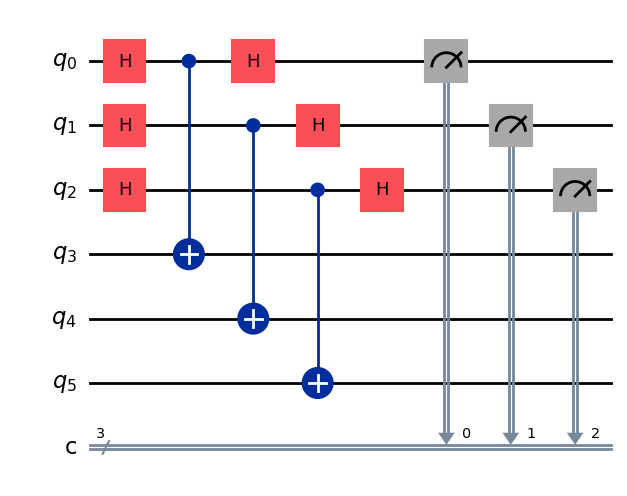

y: 011 - Count: 134
Dot Product of y and s mod 2: 0
y: 111 - Count: 119
Dot Product of y and s mod 2: 0
y: 110 - Count: 101
Dot Product of y and s mod 2: 0
y: 100 - Count: 107
Dot Product of y and s mod 2: 0
y: 001 - Count: 153
Dot Product of y and s mod 2: 0
y: 101 - Count: 123
Dot Product of y and s mod 2: 0
y: 010 - Count: 129
Dot Product of y and s mod 2: 0
y: 000 - Count: 134
Dot Product of y and s mod 2: 0
3-bit strings y for which mod 2 dot product with unknown bitstring s yields 0. Using this information, we would setup a system of equations to thus retrieve s


In [67]:
run_simon(3, '000')